loading yahoo finance


In [1]:
#1a

#import relevant libraries
import numpy as np
import pandas as pd
import pandas_datareader as dr
#define the url
import requests
sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
header = {
  "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36",
  "X-Requested-With": "XMLHttpRequest"
}

r = requests.get(sp500_url, headers=header)
data_table=pd.read_html(r.text)[1]

/tmp/ipython-input-1783947270.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  data_table=pd.read_html(r.text)[1]


In [2]:
#displays table
data_table

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [3]:
#the symbols of all 500 companies
data_table['Symbol']

,Symbol
0,MMM
1,AOS
2,ABT
3,ABBV
4,ACN
...,...
498,XYL
499,YUM
500,ZBRA
501,ZBH


In [4]:
#1b

import yfinance as yf
!pip install yahoofinancials
from yahoofinancials import YahooFinancials
from datetime import datetime
#define start and end date
start = "2022-01-01"
end = "2025-01-01"
#read data stock price data (for example appl)
Data_stock_price = yf.download(data_table['Symbol'].values.tolist(), start = start,end = end)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=91ad867ab507fa07f773f1bf7619737c63d545c3fc923c7dbac4b92084dd70de
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


/tmp/ipython-input-3205961400.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Data_stock_price = yf.download(data_table['Symbol'].values.tolist(), start = start,end = end)
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['SOLS', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01)')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


In [5]:
#loads table but missing data in the first 4 rows
Data_stock_price

Price      Adj Close                      Close                          \
Ticker          BF.B BRK.B   Q SOLS           A        AAPL        ABBV   
Date                                                                      
2022-01-03       NaN   NaN NaN  NaN  152.320038  178.270309  116.779297   
2022-01-04       NaN   NaN NaN  NaN  147.170670  176.007767  116.555084   
2022-01-05       NaN   NaN NaN  NaN  144.649567  171.326019  117.167343   
2022-01-06       NaN   NaN NaN  NaN  145.155685  168.466049  116.615456   
2022-01-07       NaN   NaN NaN  NaN  141.291229  168.632507  116.313622   
...              ...   ...  ..  ...         ...         ...         ...   
2024-12-24       NaN   NaN NaN  NaN  135.004913  257.037506  173.918823   
2024-12-26       NaN   NaN NaN  NaN  134.737106  257.853790  173.145844   
2024-12-27       NaN   NaN NaN  NaN  134.449417  254.439224  171.996017   
2024-12-30       NaN   NaN NaN  NaN  133.338425  251.064499  170.247192   
2024-12-31       NaN   NaN NaN  NaN  133.505386  249.292511  171.696503   

Price                                          ...   Volume                    \
Ticker            ABNB         ABT       ACGL  ...       WY     WYNN      XEL   
Date                                           ...                              
2022-01-03  172.679993  128.996140  42.362530  ...  3831100  2437800  3501100   
2022-01-04  170.800003  125.962334  42.914051  ...  3089700  2292300  4197000   
2022-01-05  162.250000  125.396385  42.410072  ...  3737600  3439900  4166000   
2022-01-06  159.750000  125.377831  42.657307  ...  3315200  2583200  2296000   
2022-01-07  166.050003  125.767494  42.856995  ...  3309900  1720400  2673100   
...                ...         ...        ...  ...      ...      ...      ...   
2024-12-24  134.990005  112.625931  92.669998  ...  1780100   692800   943900   
2024-12-26  135.320007  113.126434  92.930000  ...  1736500  1218900  1394900   
2024-12-27  133.384995  112.851646  92.339996  ...  2320500  1086700  2015000   
2024-12-30  131.809998  110.702370  91.889999  ...  2914700  2180100  2642900   
2024-12-31  131.410004  111.006607  92.349998  ...  3125200  1612600  2143800   

Price                                                                       
Ticker           XOM      XYL       XYZ      YUM      ZBH    ZBRA      ZTS  
Date                                                                        
2022-01-03  24282400   759100   7315700  1251400  1184809  272600  2772700  
2022-01-04  38584000   925400  14768500   935900  1400800  346000  4664000  
2022-01-05  34033300  1090200  17546200   977900  1895715  403700  4749400  
2022-01-06  30668500   703400  16244200   862400  1088813  338300  3103400  
2022-01-07  23985400   765000   9426000   833700  1690230  432800  2206500  
...              ...      ...       ...      ...      ...     ...      ...  
2024-12-24   7807000   379300   2197700   533000   458600   88700  1023600  
2024-12-26   9652400   575700   2991100  1040900  1277300  140100  2167200  
2024-12-27  11943900   552400   4140800  1146300   743400  287200  1800100  
2024-12-30  11080800   586800   5383800  1144600  1532000  211300  1531400  
2024-12-31  12387800   641600   4989400  1217100   683300  327900  1327400  

[753 rows x 2519 columns]

In [6]:
#1c

#prints table with nan for missing vlaues
Data_stock_price = Data_stock_price[~np.isnan(Data_stock_price)]
#removes nan
Data_stock_price = Data_stock_price.drop([('Adj Close', 'BF.B'), ('Adj Close','BRK.B'), ('Adj Close','Q'), ('Adj Close','SOLS')], axis=1)

In [7]:
#checks to see if data quality has improved
Data_stock_price

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  152.320038  178.270309  116.779297  172.679993  128.996140   
2022-01-04  147.170670  176.007767  116.555084  170.800003  125.962334   
2022-01-05  144.649567  171.326019  117.167343  162.250000  125.396385   
2022-01-06  145.155685  168.466049  116.615456  159.750000  125.377831   
2022-01-07  141.291229  168.632507  116.313622  166.050003  125.767494   
...                ...         ...         ...         ...         ...   
2024-12-24  135.004913  257.037506  173.918823  134.990005  112.625931   
2024-12-26  134.737106  257.853790  173.145844  135.320007  113.126434   
2024-12-27  134.449417  254.439224  171.996017  133.384995  112.851646   
2024-12-30  133.338425  251.064499  170.247192  131.809998  110.702370   
2024-12-31  133.505386  249.292511  171.696503  131.410004  111.006607   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  383.711945  564.369995  165.624557  60.489792  ...   
2022-01-04  42.914051  380.969849  554.000000  164.128647  61.612450  ...   
2022-01-05  42.410072  374.260681  514.429993  161.594971  61.131321  ...   
2022-01-06  42.657307  356.187561  514.119995  162.109146  61.674809  ...   
2022-01-07  42.856995  349.355896  510.700012  157.855209  62.200508  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  356.539642  447.940002  215.309525  48.728619  ...   
2024-12-26  92.930000  355.356506  450.160004  215.279907  48.709370  ...   
2024-12-27  92.339996  351.166351  446.480011  214.223557  48.680496  ...   
2024-12-30  91.889999  347.528290  445.799988  209.850037  48.189648  ...   
2024-12-31  92.349998  346.838135  444.679993  209.751312  48.622749  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[753 rows x 2515 columns]

In [8]:
#2a

#calculate the daily return amd annual volatility
import math
daily_returns = Data_stock_price ['Close'].pct_change()
annual_volatility = daily_returns.std() * math.sqrt(252)

/tmp/ipython-input-1105597528.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = Data_stock_price ['Close'].pct_change()


In [9]:
#2b

#import libraries
import yfinance as yf
import pandas as pd

#initiate the function
def betas(markets, stocks, start_date, end_date):
#download the historical data for the index/market
  market = yf.download(markets, start_date, end_date)
  market['stock_name'] = markets
#calculate daily returns
  market['daily_return'] = market['Close'].pct_change(1)
#calculate standard deviation of the returns
  market_std = market['daily_return'].std()
  market.dropna(inplace=True)
  market = market[['Close', 'stock_name', 'daily_return']]
#download the historical data for each stock and calculate its standard deviation
#using for loops/iteration
  frames = []
  stds = []
  for i in stocks:
    data = yf.download(i, start_date, end_date)
    data['stock_name'] = i
    data['daily_return'] = data['Close'].pct_change(1)
    data.dropna(inplace=True)
    data = data[[ 'Close', 'stock_name', 'daily_return']]
    data_std = data['daily_return'].std()
    frames.append(data)
    stds.append(data_std)
#for each stock calculate its correlation with index/market
  stock_correlation = []
  for i in frames:
    correlation = i['daily_return'].corr(market['daily_return'])
    stock_correlation.append(correlation)
#calculate beta
  betas = []
  for b,i in zip(stock_correlation, stds):
    beta_calc = b * (i/market_std)
    betas.append(beta_calc)
#form dataframe with the results
  dictionary = {stocks[e]: betas[e] for e in range(len(stocks))}
  dataframe = pd.DataFrame([dictionary]).T
  dataframe.reset_index(inplace=True)
  dataframe.rename(
    columns={"index": "Stock_Name", 0: "Beta"},
    inplace=True,)
  return dataframe

In [10]:
#2c

betas = betas('^GSPC', data_table["Symbol"], '2022-01-01', '2025-01-01')

/tmp/ipython-input-3967869168.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download(markets, start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3967869168.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3967869168.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3967869168.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(i, start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3967869168.py:23: FutureWarning: YF.download() has ch

In [11]:
betas

,Stock_Name,Beta
0,MMM,0.783737
1,AOS,0.924451
2,ABT,0.672317
3,ABBV,0.299098
4,ACN,1.094208
...,...,...
498,XYL,1.067702
499,YUM,0.633410
500,ZBRA,1.500189
501,ZBH,0.736503


In [12]:
#checkoing data types
betas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Stock_Name  503 non-null    object 
 1   Beta        499 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.0+ KB


In [13]:
X= betas[['Beta']]

In [14]:
#remobing missing vlaues
betas.dropna(subset = ['Beta'], inplace=True)

In [15]:
#cehcking for missing values
print(X.isna().sum())

Beta    4
dtype: int64


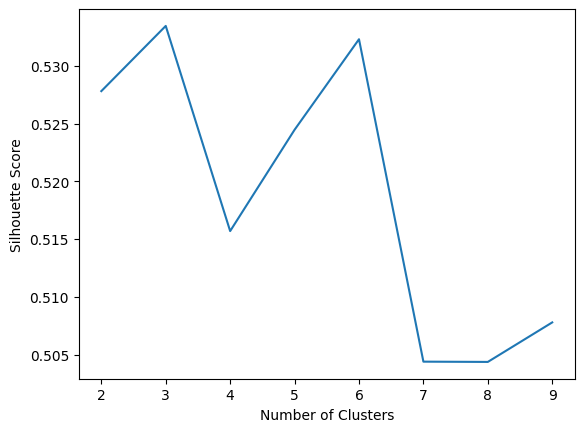

In [16]:
#3a

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
#assigning Beta column to X
X = betas[['Beta']]
#testing number of cluster from 2 to 10 and collecting the silhouette scores
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for n_clusters in range_n_clusters:
  agglom = AgglomerativeClustering(n_clusters=n_clusters)
  agglom.fit(X)
  labels = agglom.labels_
  scores.append(silhouette_score(X, labels))
#looking at the scores, and their average/mean
scores
average = sum(scores)/len(scores)
#graphing
plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [17]:
average

np.float64(0.5187794461491483)

Cluster 1 has 265 observations
Cluster 2 has 234 observations


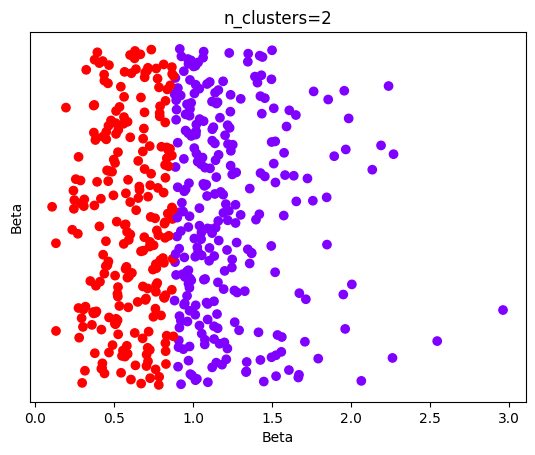

Cluster 1 has 234 observations
Cluster 2 has 77 observations
Cluster 3 has 188 observations


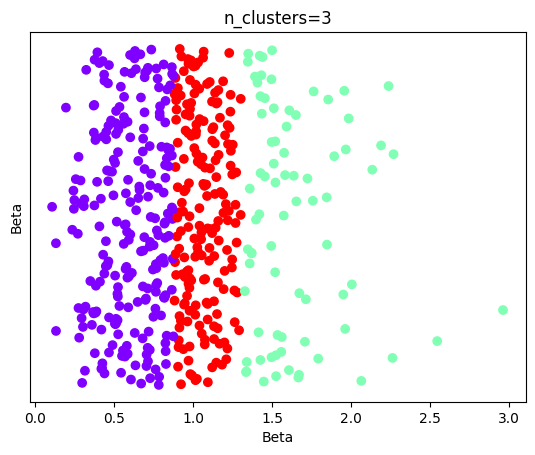

Cluster 1 has 77 observations
Cluster 2 has 126 observations
Cluster 3 has 188 observations
Cluster 4 has 108 observations


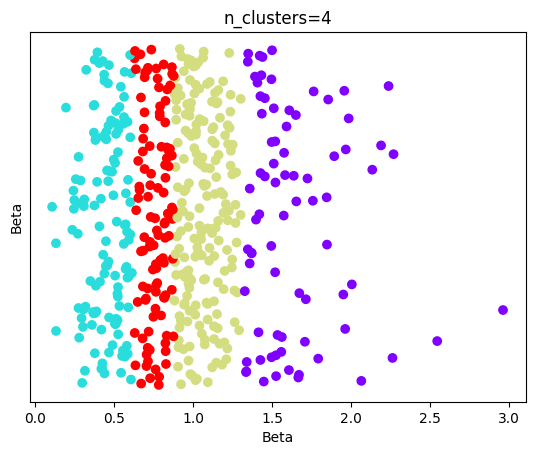

Cluster 1 has 188 observations
Cluster 2 has 126 observations
Cluster 3 has 18 observations
Cluster 4 has 108 observations
Cluster 5 has 59 observations


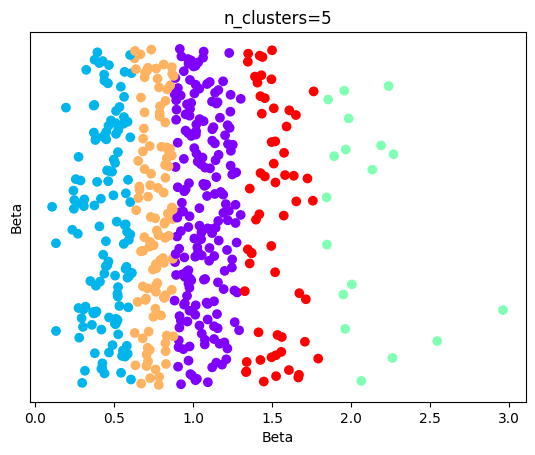

Cluster 1 has 126 observations
Cluster 2 has 59 observations
Cluster 3 has 18 observations
Cluster 4 has 108 observations
Cluster 5 has 123 observations
Cluster 6 has 65 observations


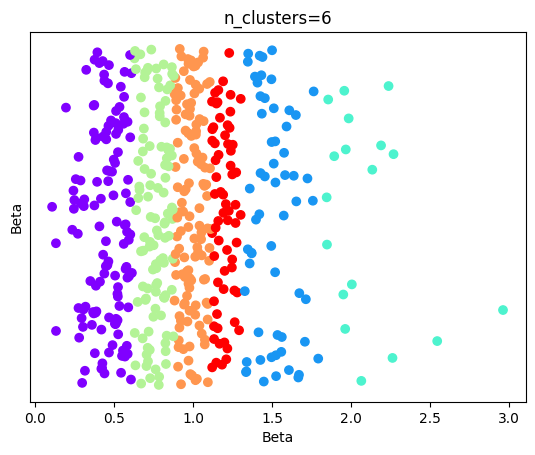

Cluster 1 has 18 observations
Cluster 2 has 59 observations
Cluster 3 has 71 observations
Cluster 4 has 108 observations
Cluster 5 has 123 observations
Cluster 6 has 65 observations
Cluster 7 has 55 observations


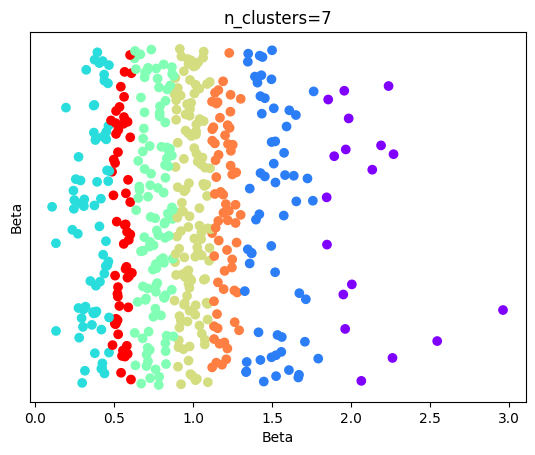

Cluster 1 has 59 observations
Cluster 2 has 108 observations
Cluster 3 has 71 observations
Cluster 4 has 16 observations
Cluster 5 has 123 observations
Cluster 6 has 65 observations
Cluster 7 has 55 observations
Cluster 8 has 2 observations


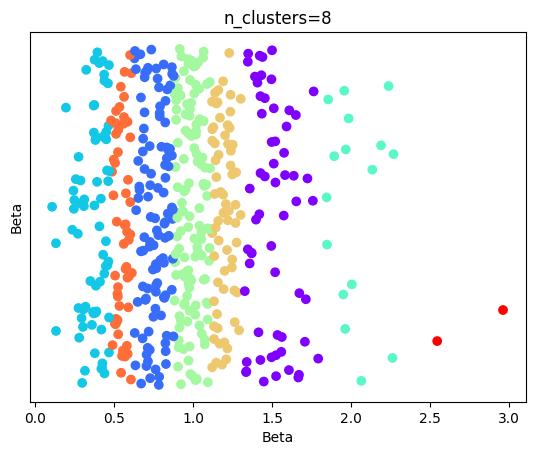

Cluster 1 has 108 observations
Cluster 2 has 123 observations
Cluster 3 has 71 observations
Cluster 4 has 16 observations
Cluster 5 has 39 observations
Cluster 6 has 65 observations
Cluster 7 has 55 observations
Cluster 8 has 2 observations
Cluster 9 has 20 observations


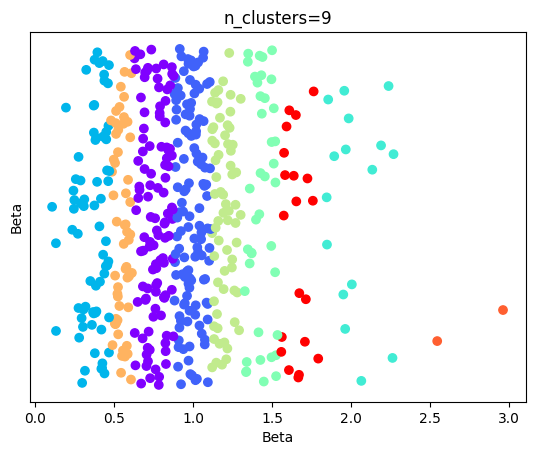

In [18]:
#3b

import numpy as np
for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X)
    # Create scatter plot of data points colored by cluster label
    plt.scatter(X, betas['Stock_Name'], c=labels, cmap='rainbow')
    plt.xlabel('Beta')
    plt.ylabel('Beta')
    plt.title(f"n_clusters={n_clusters}")
    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f"Cluster {i+1} has {cluster_counts[i]} observations")
    plt.yticks([])
    plt.show()

In [19]:
#3b

optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
cluster_labels = agglom.fit_predict(X)
betas['Cluster'] = cluster_labels
betas

,Stock_Name,Beta,Cluster
0,MMM,0.783737,3
1,AOS,0.924451,0
2,ABT,0.672317,3
3,ABBV,0.299098,1
4,ACN,1.094208,0
...,...,...,...
498,XYL,1.067702,0
499,YUM,0.633410,3
500,ZBRA,1.500189,4
501,ZBH,0.736503,3


/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


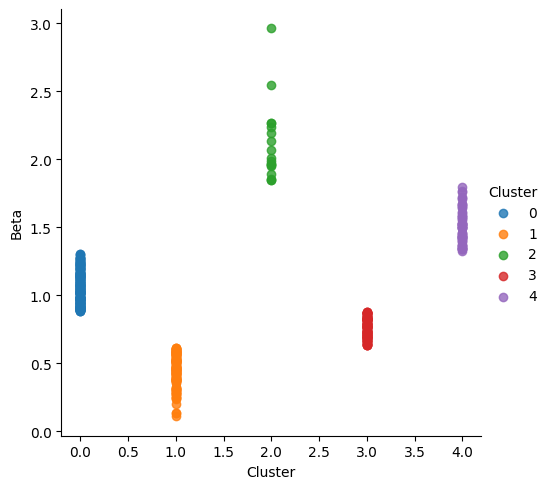

In [20]:
#3c

import seaborn as sns
cluster5 = sns.lmplot(data=betas, x='Cluster', y='Beta', hue='Cluster',
                    legend=True, legend_out=True);

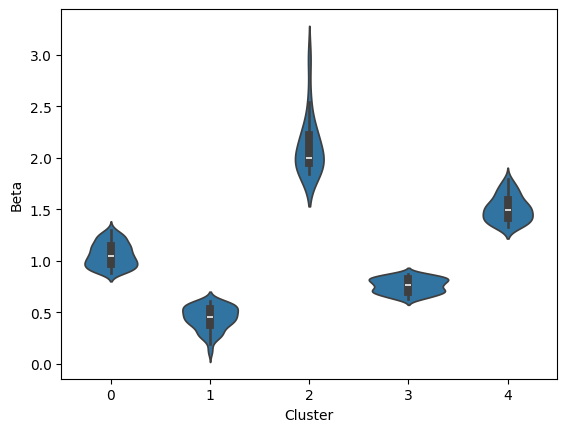

In [21]:
sns.violinplot(x='Cluster', y='Beta', data=betas)
plt.show()

In [22]:
#Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

In [23]:
#Importing KMeans from sklearn
from sklearn.cluster import KMeans

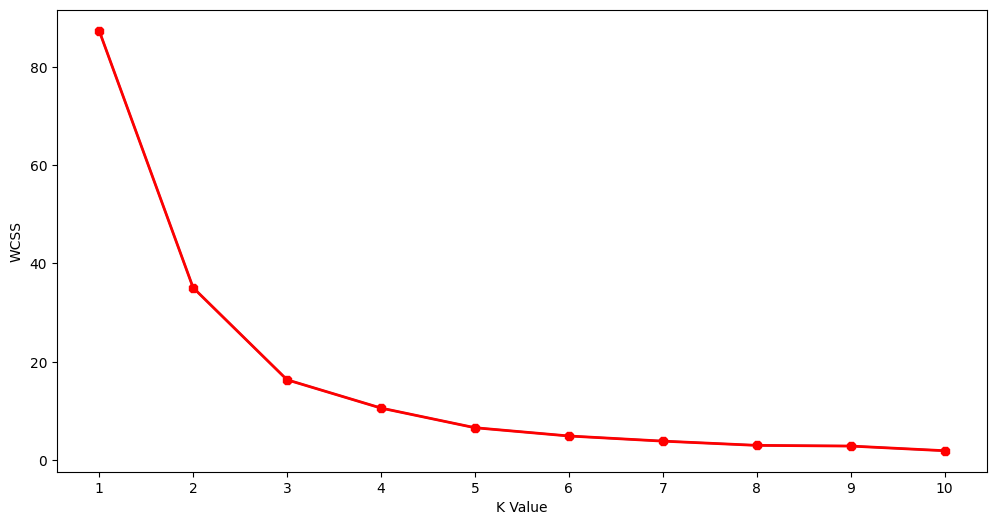

In [24]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i)
    km.fit(X)
    wcss.append(km.inertia_)
#The elbow curve
plt.figure(figsize=(12,6))
plt.plot(range(1,11),wcss)
plt.plot(range(1,11),wcss, linewidth=2, color="red", marker ="8")
plt.xlabel("K Value")
plt.xticks(np.arange(1,11,1))
plt.ylabel("WCSS")
plt.show()

In [25]:
betas1 = betas.set_index('Stock_Name').join(annual_volatility.rename("annualvol"))
betas1 = betas1.reset_index()
betas1

,Stock_Name,Beta,Cluster,annualvol
0,MMM,0.783737,3,0.295654
1,AOS,0.924451,0,0.278673
2,ABT,0.672317,3,0.217839
3,ABBV,0.299098,1,0.219958
4,ACN,1.094208,0,0.270331
...,...,...,...,...
494,XYL,1.067702,0,0.272685
495,YUM,0.633410,3,0.191335
496,ZBRA,1.500189,4,0.400050
497,ZBH,0.736503,3,0.245157


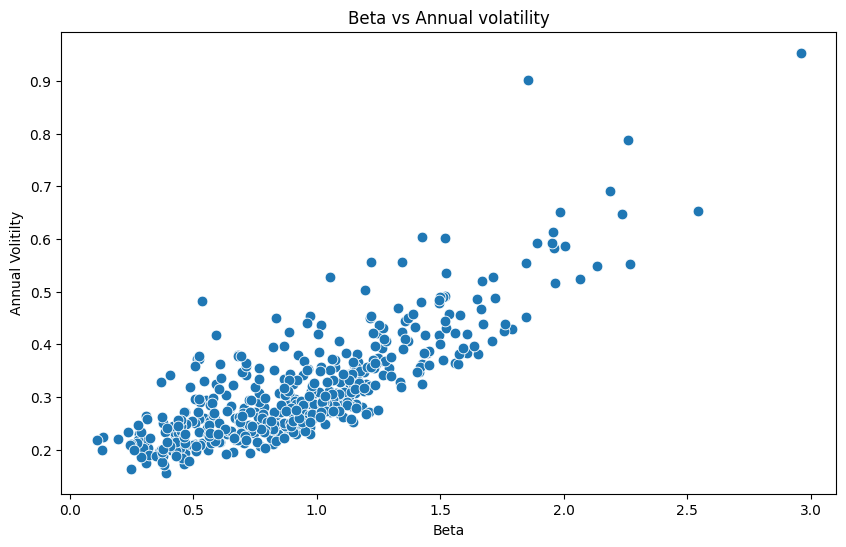

In [26]:
#Scatterplot of Annual Income and Spending score
X = betas1[['Beta', 'annualvol']]
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'Beta',y = 'annualvol',  data = X  ,s = 60 )
plt.xlabel('Beta')
plt.ylabel('Annual Volitilty')
plt.title('Beta vs Annual volatility')
plt.show()

In [27]:
#Taking 4 clusters
km1=KMeans(n_clusters=4)
#Fitting the input data
km1.fit(X)
#predicting the labels of the input data
y=km1.predict(X)
#adding the labels to a column named label
betas1["label"] = y
#The new dataframe with the clustering done
betas1.head()

,Stock_Name,Beta,Cluster,annualvol,label
0,MMM,0.783737,3,0.295654,0
1,AOS,0.924451,0,0.278673,0
2,ABT,0.672317,3,0.217839,0
3,ABBV,0.299098,1,0.219958,3
4,ACN,1.094208,0,0.270331,2


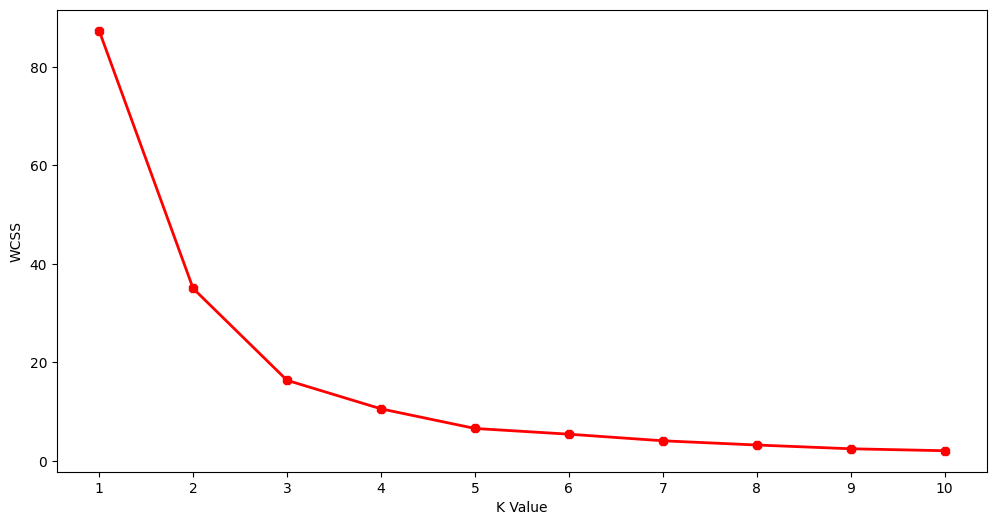

In [28]:
#Taking the features
X2= betas[["Beta"]]
#Now we calculate the Within Cluster Sum of Squared Errors (WSS) for different values of k.
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X2)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(12,6))
plt.plot(range(1,11),wcss, linewidth=2, color="red", marker ="8")
plt.xlabel("K Value")
plt.xticks(np.arange(1,11,1))
plt.ylabel("WCSS")
plt.show()

In [29]:
#We choose the k for which WSS starts to diminish
km2 = KMeans(n_clusters=4)
y2 = km2.fit_predict(X2)
betas["label"] = y2
#The data with labels
betas.head()

,Stock_Name,Beta,Cluster,label
0,MMM,0.783737,3,3
1,AOS,0.924451,0,3
2,ABT,0.672317,3,3
3,ABBV,0.299098,1,1
4,ACN,1.094208,0,0


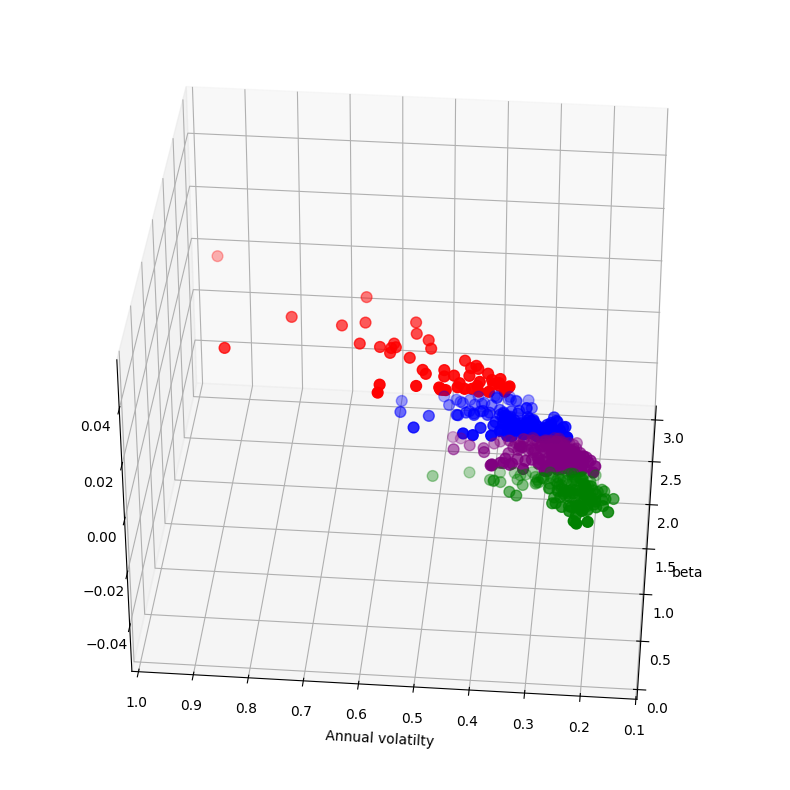

In [30]:
#3D Plot as we did the clustering on the basis of 3 input features
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(betas1["Beta"][betas1.label == 0], betas1["annualvol"][betas1.label == 0], c='purple', s=60)
ax.scatter(betas1["Beta"][betas1.label == 1], betas1["annualvol"][betas1.label == 1], c='red', s=60)
ax.scatter(betas1["Beta"][betas1.label == 2], betas1["annualvol"][betas1.label == 2], c='blue', s=60)
ax.scatter(betas1["Beta"][betas1.label == 3], betas1["annualvol"][betas1.label == 3], c='green', s=60)
ax.scatter(betas1["Beta"][betas1.label == 4], betas1["annualvol"][betas1.label == 4], c='yellow', s=60)
ax.view_init(35, 185)
plt.xlabel("beta")
plt.ylabel("Annual volatilty")
plt.show()

In [31]:
cust1=betas1[betas1["label"]==1]
print('Number of customer in 1st group=', len(cust1))
print('They are -', cust1["Stock_Name"].values)
print("--------------------------------------------")
cust2=betas1[betas1["label"]==2]
print('Number of customer in 2nd group=', len(cust2))
print('They are -', cust2["Stock_Name"].values)
print("--------------------------------------------")
cust3=betas1[betas1["label"]==0]
print('Number of customer in 3rd group=', len(cust3))
print('They are -', cust3["Stock_Name"].values)
print("--------------------------------------------")
cust4=betas1[betas1["label"]==3]
print('Number of customer in 4th group=', len(cust4))
print('They are -', cust4["Stock_Name"].values)
print("--------------------------------------------")
cust5=betas1[betas1["label"]==4]
print('Number of customer in 5th group=', len(cust5))
print('They are -', cust5["Stock_Name"].values)
print("--------------------------------------------")

Number of customer in 1st group= 52
They are - ['AMD' 'ABNB' 'ALB' 'ALGN' 'AMZN' 'AMAT' 'APP' 'APTV' 'ANET' 'ADSK' 'BX'
 'XYZ' 'AVGO' 'BLDR' 'CCL' 'COIN' 'CRWD' 'DDOG' 'DAY' 'DASH' 'EPAM' 'GEV'
 'GNRC' 'INTU' 'KKR' 'KLAC' 'LRCX' 'MTCH' 'META' 'MCHP' 'MU' 'MRNA' 'MPWR'
 'NFLX' 'NCLH' 'NVDA' 'NXPI' 'ON' 'PLTR' 'PAYC' 'PYPL' 'QCOM' 'HOOD' 'RCL'
 'NOW' 'SWKS' 'SMCI' 'TER' 'TSLA' 'TTD' 'UBER' 'ZBRA']
--------------------------------------------
Number of customer in 2nd group= 140
They are - ['ACN' 'ADBE' 'AES' 'A' 'GOOGL' 'GOOG' 'AXP' 'AMP' 'APH' 'ADI' 'APO'
 'AAPL' 'AXON' 'BBY' 'TECH' 'BLK' 'BA' 'BKNG' 'BXP' 'CDNS' 'COF' 'CARR'
 'CBRE' 'CDW' 'CRL' 'CMG' 'C' 'CFG' 'CEG' 'CPRT' 'CPAY' 'CSGP' 'DECK'
 'DELL' 'DAL' 'DXCM' 'DHI' 'ETN' 'EBAY' 'EFX' 'EL' 'EXPE' 'FFIV' 'FICO'
 'FIS' 'FITB' 'FSLR' 'F' 'FTNT' 'FTV' 'BEN' 'FCX' 'IT' 'GE' 'GM' 'GPN'
 'GDDY' 'HPE' 'HLT' 'HST' 'HWM' 'HPQ' 'HBAN' 'IDXX' 'IR' 'PODD' 'INTC'
 'ISRG' 'IVZ' 'IQV' 'JBL' 'JCI' 'KEY' 'KEYS' 'LVS' 'LEN' 'LII' 'LYV'
 'LULU' 'MAR' 

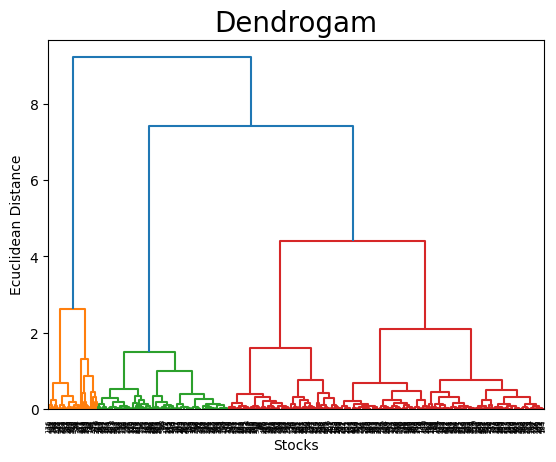

In [32]:
#Hierarchical agglomerative clustering (HAC)
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogam', fontsize = 20)
plt.xlabel('Stocks')
plt.ylabel('Ecuclidean Distance')
plt.show()

In [33]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, linkage = 'ward')
y_hc = hc.fit_predict(X)
agglo1=betas1[["Beta","annualvol"]]
agglo1["label"] = y_hc
agglo1

/tmp/ipython-input-3101404908.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agglo1["label"] = y_hc


,Beta,annualvol,label
0,0.783737,0.295654,0
1,0.924451,0.278673,0
2,0.672317,0.217839,0
3,0.299098,0.219958,2
4,1.094208,0.270331,1
...,...,...,...
494,1.067702,0.272685,1
495,0.633410,0.191335,0
496,1.500189,0.400050,4
497,0.736503,0.245157,0


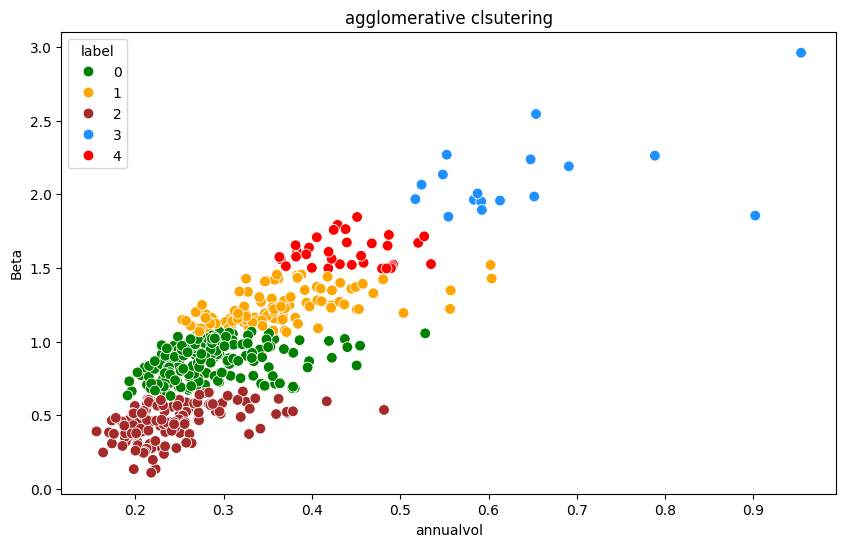

In [34]:
#Scatterplot of the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'annualvol',y = 'Beta',hue="label",
                 palette=['green','orange','brown','dodgerblue','red'], legend='full',data = agglo1  ,s = 60 )
plt.xlabel('annualvol')
plt.ylabel('Beta')
plt.title('agglomerative clsutering')
plt.show()

In [35]:
cust6=agglo1[agglo1["label"]==1]
print('Number of customer in 1st group=', len(cust6))
print('They are -', cust1["Stock_Name"].values)
print("--------------------------------------------")
cust7=agglo1[agglo1["label"]==2]
print('Number of customer in 2nd group=', len(cust7))
print('They are -', cust2["Stock_Name"].values)
print("--------------------------------------------")
cust8=agglo1[agglo1["label"]==0]
print('Number of customer in 3rd group=', len(cust8))
print('They are -', cust3["Stock_Name"].values)
print("--------------------------------------------")
cust9=agglo1[agglo1["label"]==3]
print('Number of customer in 4th group=', len(cust9))
print('They are -', cust4["Stock_Name"].values)
print("--------------------------------------------")
cust10=agglo1[agglo1["label"]==4]
print('Number of customer in 5th group=', len(cust10))
print('They are -', cust5["Stock_Name"].values)
print("--------------------------------------------")

Number of customer in 1st group= 113
They are - ['AMD' 'ABNB' 'ALB' 'ALGN' 'AMZN' 'AMAT' 'APP' 'APTV' 'ANET' 'ADSK' 'BX'
 'XYZ' 'AVGO' 'BLDR' 'CCL' 'COIN' 'CRWD' 'DDOG' 'DAY' 'DASH' 'EPAM' 'GEV'
 'GNRC' 'INTU' 'KKR' 'KLAC' 'LRCX' 'MTCH' 'META' 'MCHP' 'MU' 'MRNA' 'MPWR'
 'NFLX' 'NCLH' 'NVDA' 'NXPI' 'ON' 'PLTR' 'PAYC' 'PYPL' 'QCOM' 'HOOD' 'RCL'
 'NOW' 'SWKS' 'SMCI' 'TER' 'TSLA' 'TTD' 'UBER' 'ZBRA']
--------------------------------------------
Number of customer in 2nd group= 131
They are - ['ACN' 'ADBE' 'AES' 'A' 'GOOGL' 'GOOG' 'AXP' 'AMP' 'APH' 'ADI' 'APO'
 'AAPL' 'AXON' 'BBY' 'TECH' 'BLK' 'BA' 'BKNG' 'BXP' 'CDNS' 'COF' 'CARR'
 'CBRE' 'CDW' 'CRL' 'CMG' 'C' 'CFG' 'CEG' 'CPRT' 'CPAY' 'CSGP' 'DECK'
 'DELL' 'DAL' 'DXCM' 'DHI' 'ETN' 'EBAY' 'EFX' 'EL' 'EXPE' 'FFIV' 'FICO'
 'FIS' 'FITB' 'FSLR' 'F' 'FTNT' 'FTV' 'BEN' 'FCX' 'IT' 'GE' 'GM' 'GPN'
 'GDDY' 'HPE' 'HLT' 'HST' 'HWM' 'HPQ' 'HBAN' 'IDXX' 'IR' 'PODD' 'INTC'
 'ISRG' 'IVZ' 'IQV' 'JBL' 'JCI' 'KEY' 'KEYS' 'LVS' 'LEN' 'LII' 'LYV'
 'LULU' 'MAR'